# Log Transformations - Lab

## Introduction

It's time to practice some logarithmic transformations on the Ames Housing dataset!

## Objectives

You will be able to:

- Determine if a log transformation would be useful for a specific model or set of data
- Apply log transformations to independent and dependent variables in linear regression
- Interpret the coefficients of variables that have been transformed using a log transformation

## Ames Housing Data

Below we load the numeric features from the Ames Housing dataset into a dataframe. We also drop any rows with missing data.

In [15]:
# Run this cell without changes
import pandas as pd
ames = pd.read_csv("ames.csv", index_col=0)
ames = ames.select_dtypes("number")
ames.dropna(inplace=True)
ames

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,0,61,0,0,0,0,0,2,2008,208500
2,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,298,0,0,0,0,0,0,5,2007,181500
3,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,0,42,0,0,0,0,0,9,2008,223500
4,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,0,35,272,0,0,0,0,2,2006,140000
5,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,192,84,0,0,0,0,0,12,2008,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,62.0,7917,6,5,1999,2000,0.0,0,0,...,0,40,0,0,0,0,0,8,2007,175000
1457,20,85.0,13175,6,6,1978,1988,119.0,790,163,...,349,0,0,0,0,0,0,2,2010,210000
1458,70,66.0,9042,7,9,1941,2006,0.0,275,0,...,0,60,0,0,0,0,2500,5,2010,266500


## Identify Good Candidates for Log Transformation

Below we plot each of the potential numeric features against `SalePrice`:

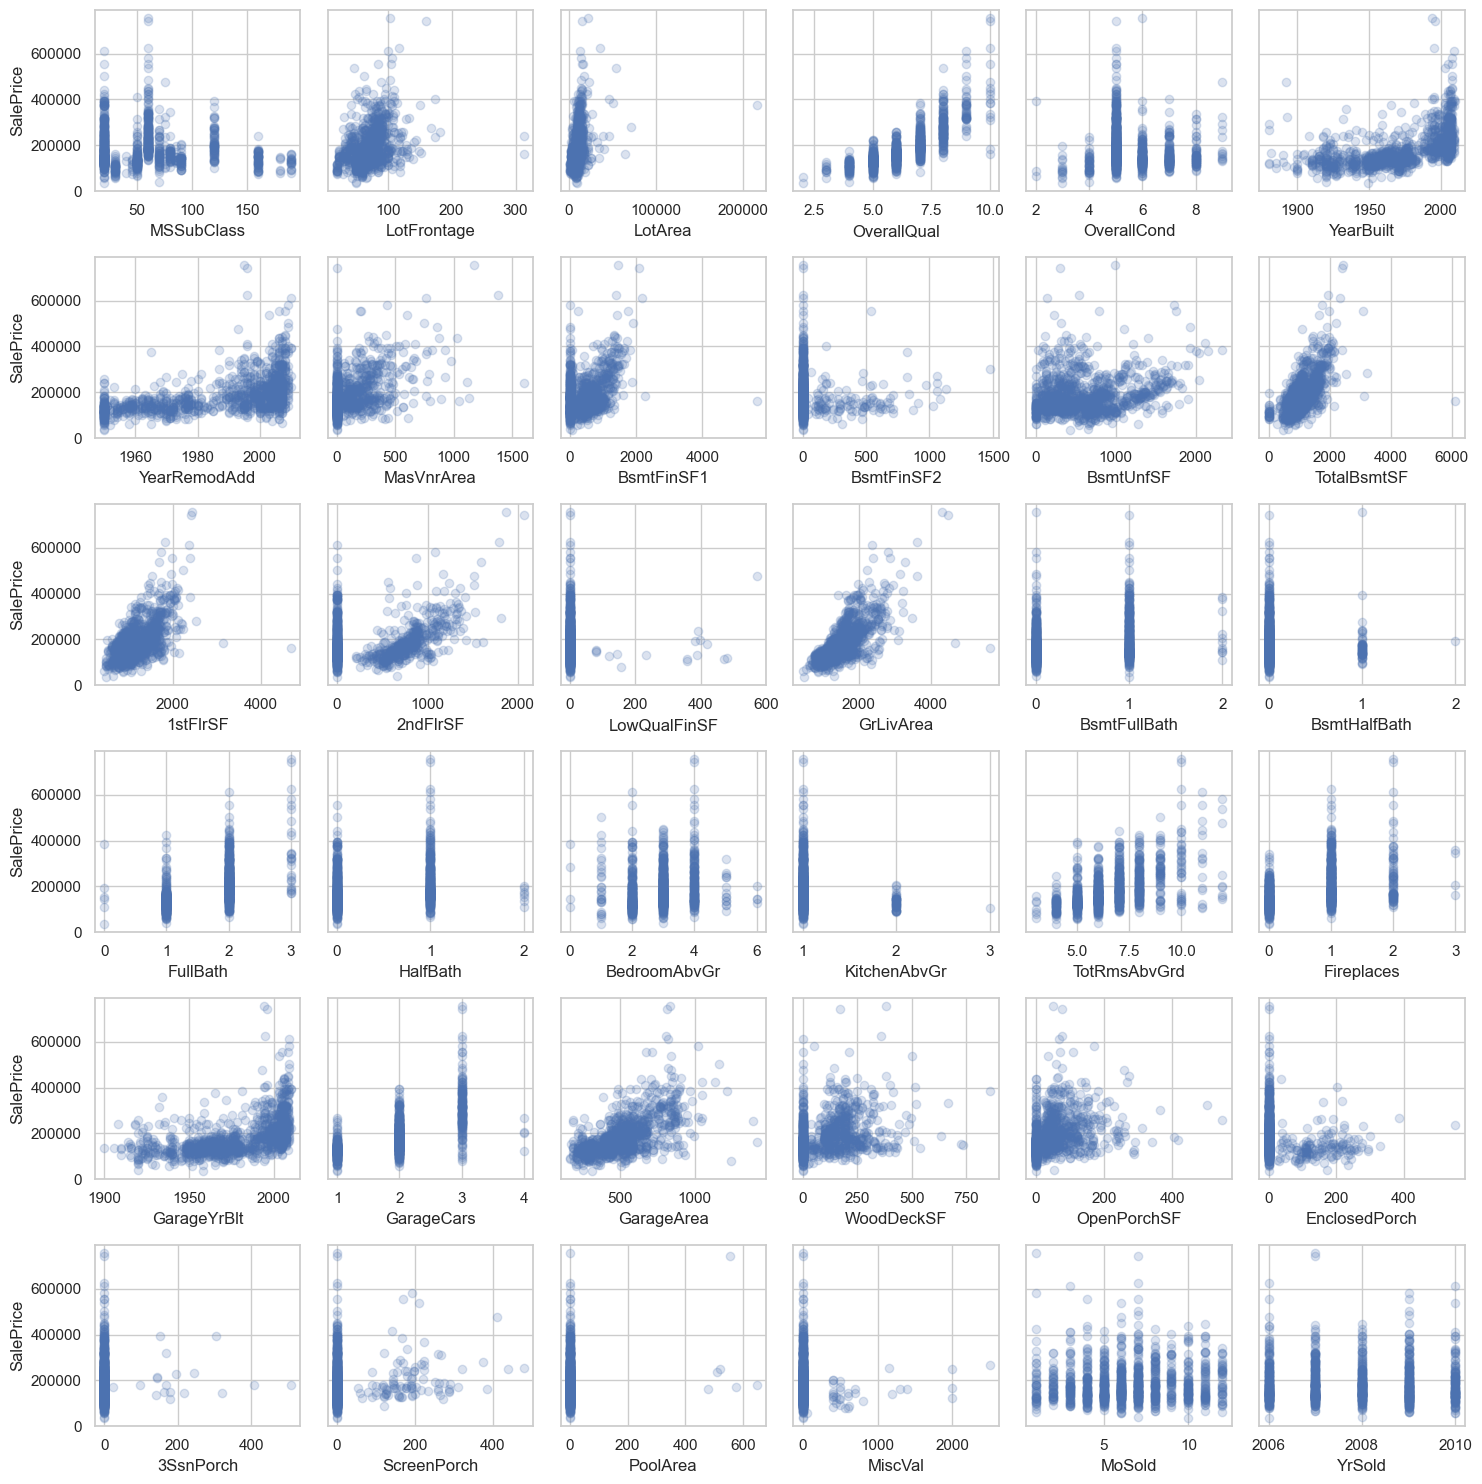

In [16]:
# Run this cell without changes
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

y = ames["SalePrice"]
X = ames.drop("SalePrice", axis=1)

fig, axes = plt.subplots(nrows=6, ncols=6, figsize=(15,15), sharey=True)

for i, column in enumerate(X.columns):
    # Locate applicable axes
    row = i // 6
    col = i % 6
    ax = axes[row][col]
    
    # Plot feature vs. y and label axes
    ax.scatter(X[column], y, alpha=0.2)
    ax.set_xlabel(column)
    if col == 0:
        ax.set_ylabel("SalePrice")

fig.tight_layout()

Let's say we want to build a model with **at least one log-transformed feature** as well as a **log-transformed target**

Do you see any features that look like good candidates for this type of transformation?

For reference, a good candidate for this might look like any of these three graphs:

---

<div align="center"><div style="background-image: url('https://upload.wikimedia.org/wikipedia/commons/thumb/0/00/Population_vs_area.svg/256px-Population_vs_area.svg.png'); height: 200px; width: 256px;"></div><a title="Skbkekas, CC BY-SA 3.0 &lt;http://creativecommons.org/licenses/by-sa/3.0/&gt;, via Wikimedia Commons" href="https://commons.wikimedia.org/wiki/File:Population_vs_area.svg">Skbkekas, CC BY-SA 3.0, via Wikimedia Commons</a></div>

---

<div align="center"><img src="http://sciences.usca.edu/biology/zelmer/305/trans/y.jpg" width="256"/>
<a href="http://sciences.usca.edu/biology/zelmer/305/trans/">Derek Zelmer, UCSA</a></div>

---

![e^x](https://curriculum-content.s3.amazonaws.com/data-science/images/log_graphs.png)

Try to find one feature that resembles each of these shapes.

Because this is real-world messy data, none of them are going to match perfectly, and that's ok!

In [17]:
# Your written answer here
""" 
GrLiveArea :Very strong exponential-looking relationship with SalePrice.

            Log-transforming both GrLivArea and SalePrice could linearize it well.

TotalBsmtSF:
           similar to GrLivArea, shows a curved upward trend—typical of a multiplicative relationship.

1stFlrSF:

          Shows a steep positive trend. Might benefit from log-log modeling.

GarageArea:

           Also appears to have a positively skewed relationship with SalePrice.

LotArea:

          Shows a lot of spread and skew. A log transformation might help compress large values.

MasVnrArea

           :Has a few very high values (outliers) and many small ones—a log transformation could normalize it.



"""


' \nGrLiveArea :Very strong exponential-looking relationship with SalePrice.\n\n            Log-transforming both GrLivArea and SalePrice could linearize it well.\n\nTotalBsmtSF:\n           similar to GrLivArea, shows a curved upward trend—typical of a multiplicative relationship.\n\n1stFlrSF:\n\n          Shows a steep positive trend. Might benefit from log-log modeling.\n\nGarageArea:\n\n           Also appears to have a positively skewed relationship with SalePrice.\n\nLotArea:\n\n          Shows a lot of spread and skew. A log transformation might help compress large values.\n\nMasVnrArea\n\n           :Has a few very high values (outliers) and many small ones—a log transformation could normalize it.\n\n\n\n'

### Plot Log Transformed Versions of Features

For each feature that you identified as a good candidate for log transformation, plot the feature vs. `SalePrice` as well as the log transformed feature vs. log transformed `SalePrice`.

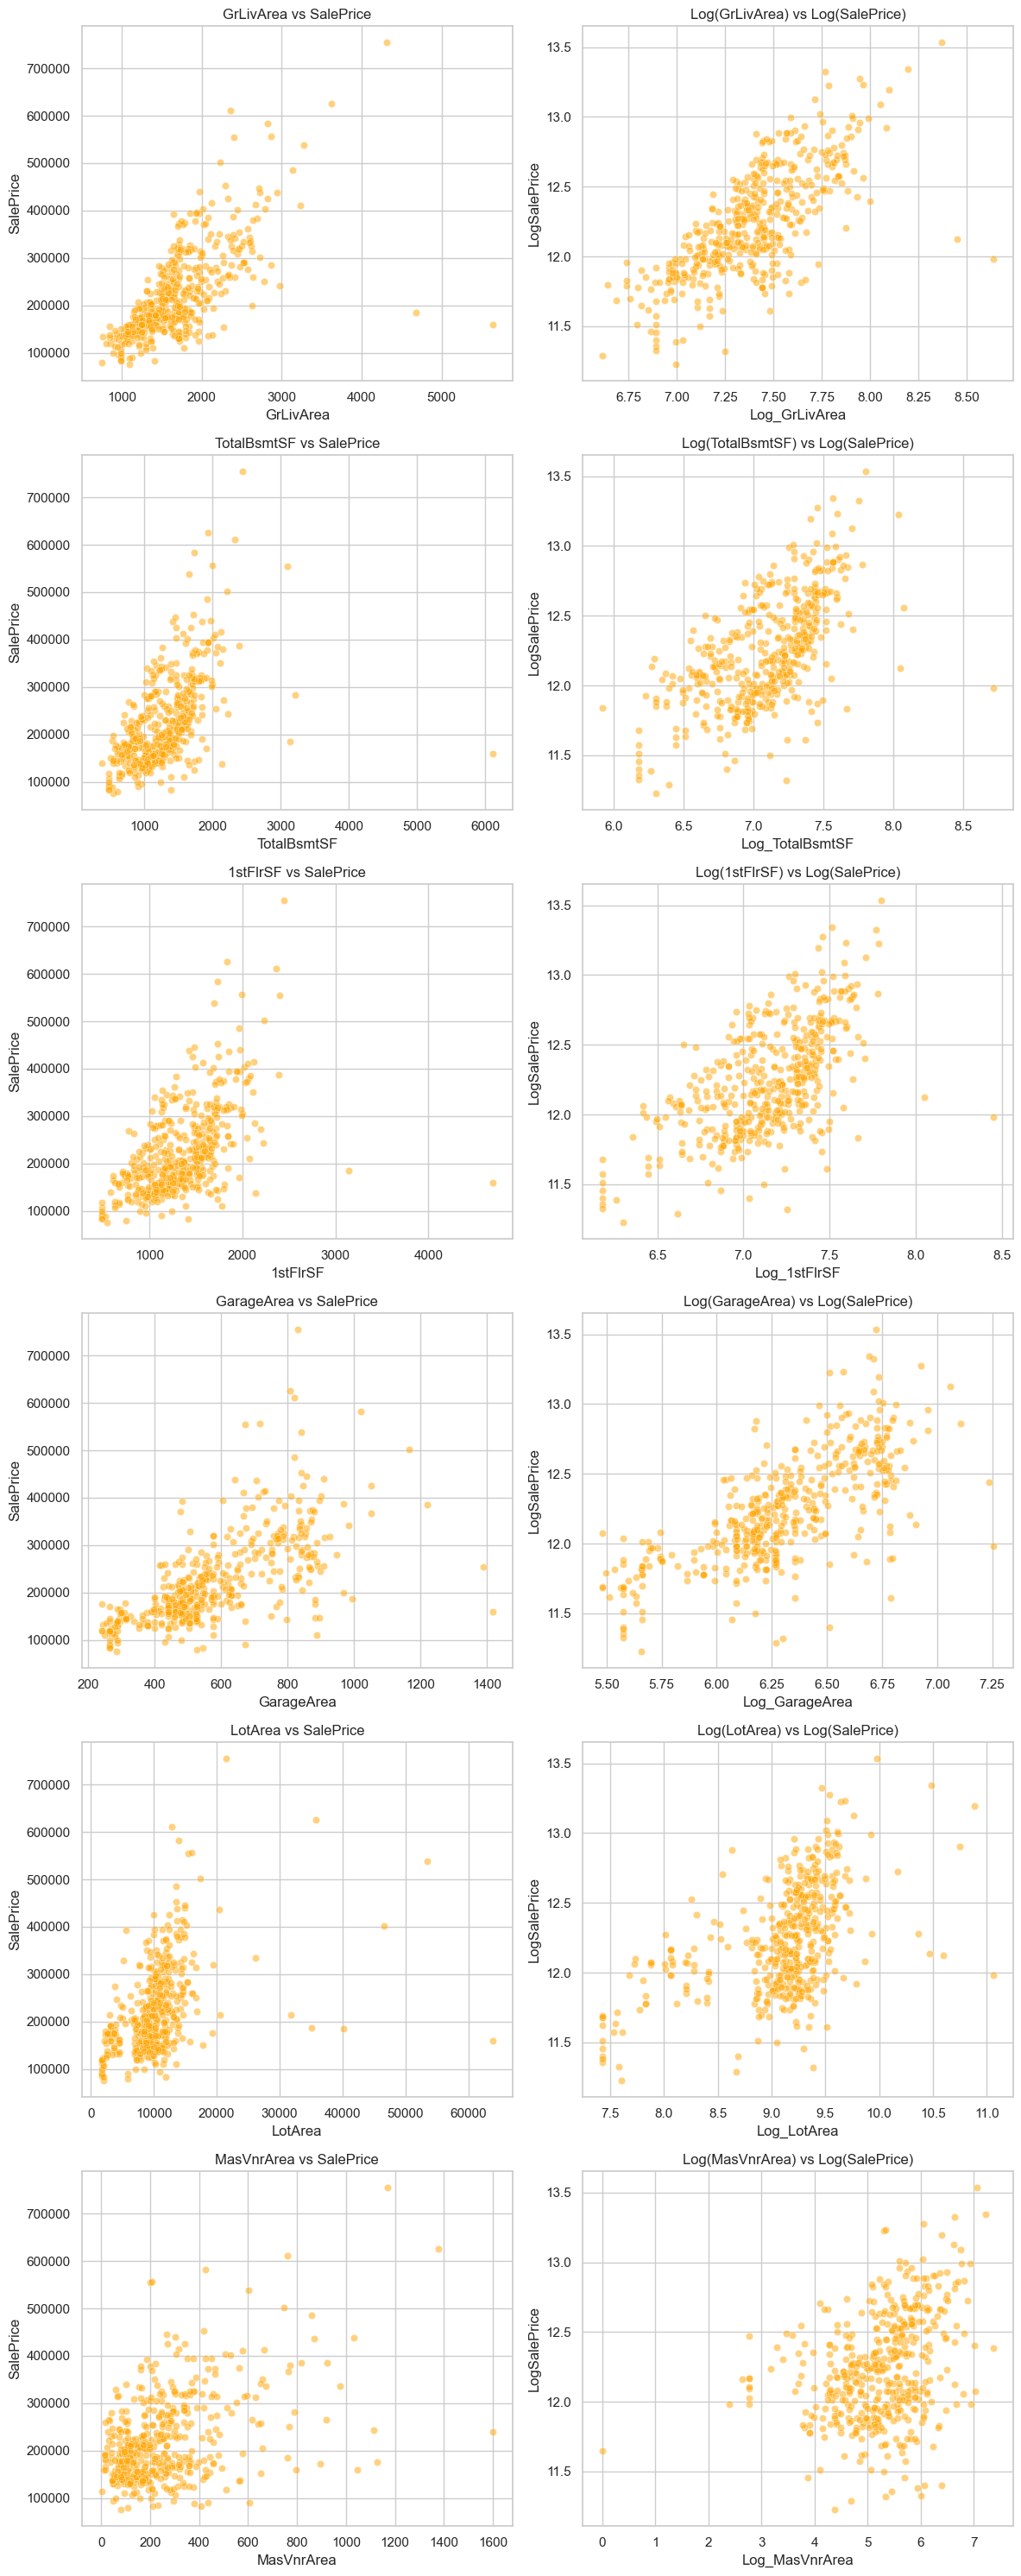

In [18]:
# Define target and features for log transformation
target = 'SalePrice'
features = ['GrLivArea', 'TotalBsmtSF', '1stFlrSF', 'GarageArea', 'LotArea', 'MasVnrArea']

# Drop rows where any of these values are zero or null (to avoid log(0))
df_filtered = ames[features + [target]].replace(0, np.nan).dropna()

# Apply log transformation
df_log = df_filtered.copy()
df_log['LogSalePrice'] = np.log(df_log[target])

for feature in features:
    df_log[f'Log_{feature}'] = np.log(df_log[feature])

# Plot original and log-log relationships
sns.set(style="whitegrid")
fig, axs = plt.subplots(len(features), 2, figsize=(12, 5 * len(features)))

for i, feature in enumerate(features):
    sns.scatterplot(data=df_filtered, x=feature, y=target, ax=axs[i, 0], color='orange', edgecolor='w', alpha=0.5)
    axs[i, 0].set_title(f'{feature} vs SalePrice')

    sns.scatterplot(data=df_log, x=f'Log_{feature}', y='LogSalePrice', ax=axs[i, 1], color='orange', edgecolor='w', alpha=0.5)
    axs[i, 1].set_title(f'Log({feature}) vs Log(SalePrice)')

plt.tight_layout()
plt.show()

Do the transformed relationships look more linear? If so, they should be included in the model.

## Build a Model with Log-Transformed Features and Target

### Data Preparation

Choose up to 3 of the features you investigated, and set up an X dataframe containing the log-transformed versions of these features as well as a y series containing the log-transformed version of the target.

---

<details>
    <summary style="cursor: pointer"><b>Hint (click to reveal)</b></summary>

If you are planning log transform a feature measured in _years_ (e.g. `YearRemodAdd`) consider shifting the data first. For example, you might subtract 1900 or 1910 from the year, so that a 1% increase in year is closer to meaning 1 year rather than 20 years.

</details>

In [19]:
# Your code here - prepare data for modeling
# Filter relevant columns and drop rows with missing or zero values
features = ['GrLivArea', 'TotalBsmtSF', 'LotArea']
df_model = ames[features + ['SalePrice']].replace(0, np.nan).dropna()

# Apply log1p transformation to handle 0 values safely (log1p(x) = log(x + 1))
X = df_model[features].apply(np.log1p)
y = np.log1p(df_model['SalePrice'])

# Display first few rows to verify
print(X.head())
print(y.head())

    GrLivArea  TotalBsmtSF   LotArea
Id                                  
1    7.444833     6.753438  9.042040
2    7.141245     7.141245  9.169623
3    7.488294     6.825460  9.328212
4    7.448916     6.629363  9.164401
5    7.695758     7.044033  9.565284
Id
1    12.247699
2    12.109016
3    12.317171
4    11.849405
5    12.429220
Name: SalePrice, dtype: float64


### Modeling

Now build a StatsModels OLS model with a log-transformed target as well as log-transformed features.

In [20]:
# Your code here - build a model
import statsmodels.api as sm
log_transformed_model=sm.OLS(y, sm.add_constant(X)).fit()

log_transformed_model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              SalePrice   R-squared:                       0.649
Model:                            OLS   Adj. R-squared:                  0.648
Method:                 Least Squares   F-statistic:                     672.6
Date:                Thu, 24 Apr 2025   Prob (F-statistic):          1.22e-247
Time:                        04:28:18   Log-Likelihood:                 37.677
No. Observations:                1097   AIC:                            -67.35
Df Residuals:                    1093   BIC:                            -47.35
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           3.9980      0.185     21.567      0.000       3.634       4.362
GrLivArea       0.6705      0.025     26.769      0.000       0.621       0.720
TotalBsmtSF     0.3935      0.022     17.525      0.000       0.349       0.438
LotArea         0.0489      0.016      3.028      0.003       0.017       0.081
==============================================================================
Omnibus:                      306.200   Durbin-Watson:                   2.036
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1401.773
Skew:                          -1.232   Prob(JB):                    4.06e-305
Kurtosis:                       7.959   Cond. No.                         358.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Model Evaluation and Interpretation

How did the model perform? How might we interpret its coefficients? Create as many cells as needed.

In [ ]:
# Your code here - evaluate the model
""" 
The model explains about 65% of the variance in Log(SalePrice)

The model is statistically significant overally with a F-statistic p-value of well less than 0.05

The coefficients of the model are all statistically significant with a t-statistic p-value of well below 0.05 

When all other variables are 1 the expected Log(SalePrice)  of a home is 3.9980

GrLivArea: for an increase in one square feet of the living area,there is an expected increase of 0.6705% in the SalePrice of the home

TotalBsmtSF: for an increase in one square feet of the TotalBsmt,there is an expected increase of 0.3935% in SalePrice of the home

LotArea: for an increase in one square feet of the LotArea, there is an expected increase of 0.0489% in SalePrice of the home

Your log-log model performs reasonably well with interpretable coefficients.

GrLivArea has the largest influence on sale price elasticity.

Residual skewness suggests that there may still be some nonlinearity or outliers to address.

You might consider adding interaction terms, polynomial features, or regularization (e.g., Lasso/Ridge) if you want to boost performance.

But overally the model performed better 
"""


' \nThe model explains about 65% of the variance in Log(SalePrice)\n\nThe model is statistically significant overally with a F-statistic p-value of well less than 0.05\n\nThe coefficients of the model are all statistically significant with a t-statistic p-value of well below 0.05 \n\nWhen all other variables are 1 the expected Log(SalePrice)  of a home is 3.9980\n\nGrLivArea: for an increase in one square feet of the living area,there is an expected increase of 0.6705% in the SalePrice of the home\n\nTotalBsmtSF: for an increase in one square feet of the TotalBsmt,there is an expected increase of 0.3935% in SalePrice of the home\n\nLotArea: for an increase in one square feet of the LotArea, there is an expected increase of 0.0489% in SalePrice of the home\n\nYour log-log model performs reasonably well with interpretable coefficients.\n\nGrLivArea has the largest influence on sale price elasticity.\n\nResidual skewness suggests that there may still be some nonlinearity or outliers to ad

## Summary

Now you have practiced modeling with log transformations! This is a subtle, messy process, so don't be discouraged if this was a tricky lab.